In [2]:
from tensorflow.keras.datasets import mnist
(X_train, y_train), (X_test, y_test) = mnist.load_data()


I0000 00:00:1775858380.115141   32695 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1775858380.166330   32695 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1775858381.779963   32695 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step


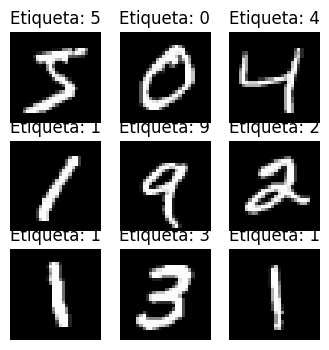

In [3]:
import matplotlib.pyplot as plt
plt.figure(figsize=(4,4))
for i in range(9):
  plt.subplot(3,3,i+1)
  plt.imshow(X_train[i], cmap='gray')
  plt.title(f"Etiqueta: {y_train[i]}")
  plt.axis('off')
plt.show()

In [4]:
X_train_raw = X_train.copy()
X_test_raw = X_test.copy()

X_train = X_train.reshape(60000, 784) / 255.0
X_test = X_test.reshape(10000, 784) / 255.0


In [5]:
from tensorflow.keras.utils import to_categorical

y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)

In [6]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input

modelo = Sequential([
Input(shape=(784,)),
Dense(128, activation='relu'),
Dense(64, activation='relu'),
Dense(10, activation='softmax')
])


E0000 00:00:1775858387.514051   32695 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


In [7]:
modelo.compile(
 optimizer='adam',
 loss='categorical_crossentropy',
 metrics=['accuracy']
 )

historial = modelo.fit(
 X_train, y_train,
 epochs=10,
 batch_size=32,
 validation_split=0.2
)


Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9237 - loss: 0.2619 - val_accuracy: 0.9532 - val_loss: 0.1516
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9669 - loss: 0.1120 - val_accuracy: 0.9683 - val_loss: 0.1057
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9764 - loss: 0.0766 - val_accuracy: 0.9698 - val_loss: 0.1060
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9810 - loss: 0.0597 - val_accuracy: 0.9653 - val_loss: 0.1193
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9857 - loss: 0.0450 - val_accuracy: 0.9708 - val_loss: 0.1026
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9890 - loss: 0.0342 - val_accuracy: 0.9731 - val_loss: 0.0965
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9897 - loss: 0.0322 - val_accuracy: 0.9750 - val_loss: 0.0943
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9913 - loss: 0.0258 - 

In [8]:
loss, acc = modelo.evaluate(X_test, y_test)
print(f"Exactitud en prueba: {acc:.4f}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.9780 - loss: 0.0858
Exactitud en prueba: 0.9780


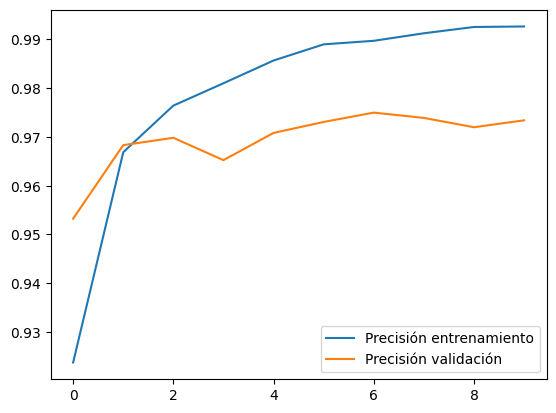

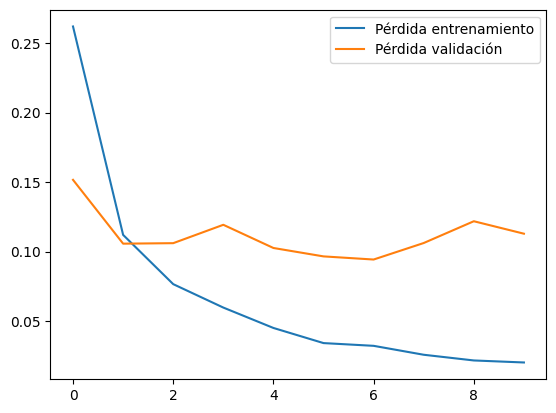

In [9]:
plt.plot(historial.history['accuracy'], label='Precisión entrenamiento')
plt.plot(historial.history['val_accuracy'], label='Precisión validación')
plt.legend()
plt.show()

plt.plot(historial.history['loss'], label='Pérdida entrenamiento')
plt.plot(historial.history['val_loss'], label='Pérdida validación')
plt.legend()
plt.show()

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  


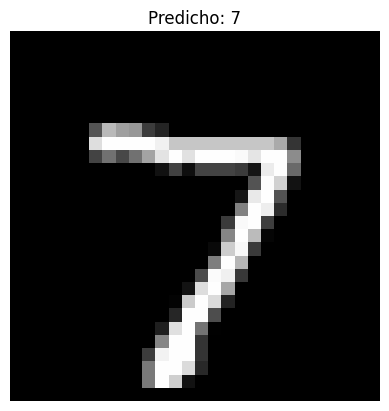

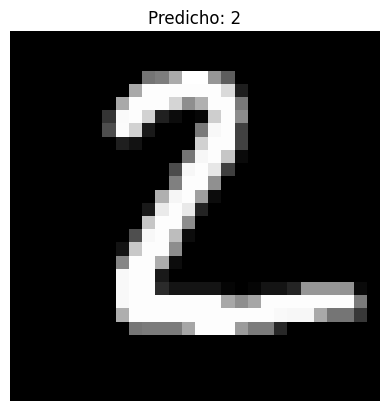

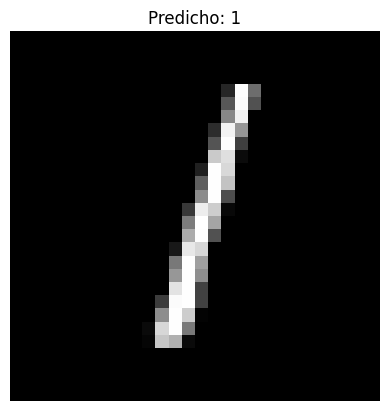

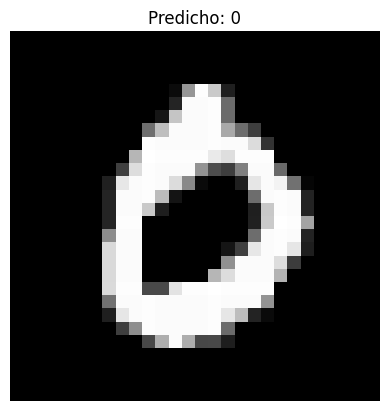

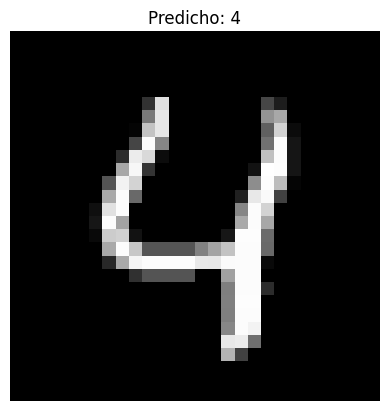

In [10]:
import numpy as np

pred = modelo.predict(X_test)

for i in range(5):
  plt.imshow(X_test_raw[i], cmap='gray')
  plt.title(f"Predicho: {np.argmax(pred[i])}")
  plt.axis('off')
  plt.show()

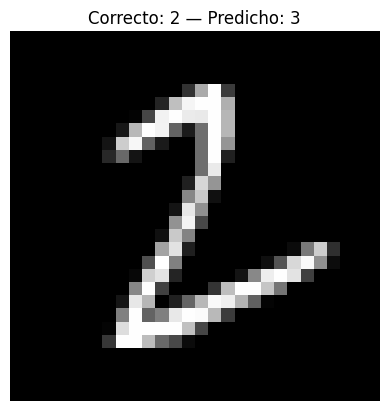

In [11]:
y_test_labels = np.argmax(y_test, axis=1)
errores = np.where(np.argmax(pred, axis=1) != y_test_labels)[0]

i = errores[0]
plt.imshow(X_test_raw[i], cmap='gray')
plt.title(f"Correcto: {y_test_labels[i]} — Predicho: {np.argmax(pred[i])}")
plt.axis('off')
plt.show()